In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import croak

In [2]:
g = croak.Grid(128, dt=0.3e-15)                       # 128 points, 0.3 fs step
omega0 = croak.maths.wlfreq(800e-9)                   # 800 nm carrier
ew = croak.gaussian_pulse(g, 2.5e-15, phases=[4e-30]) # phases = [GDD, TOD, ...] in SI

# the temporal intensity of the true pulse
field_true = g.ifft(ew)
I_true = np.abs(field_true) ** 2
fwhm_true = croak.maths.fwhm(g.t, I_true) * 1e15
print(f"true temporal FWHM = {fwhm_true:.2f} fs")

true temporal FWHM = 5.10 fs


In [3]:
delays = np.linspace(-18e-15, 18e-15, 87)
trace = croak.maketrace(g.omega, delays, ew, "shg")
trace.shape

(128, 87)

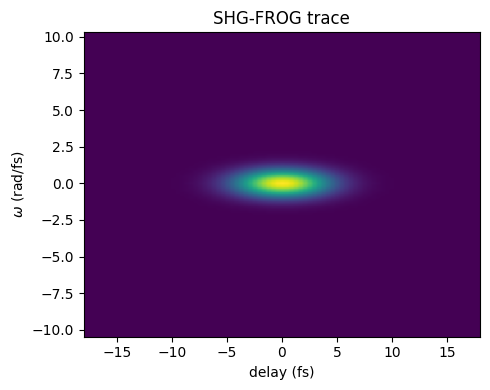

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(trace, aspect="auto", origin="lower",
          extent=[delays[0] * 1e15, delays[-1] * 1e15,
                  g.omega[0] / 1e15, g.omega[-1] / 1e15])
ax.set_xlabel("delay (fs)")
ax.set_ylabel(r"$\omega$ (rad/fs)")
ax.set_title("SHG-FROG trace")
fig.tight_layout()

In [5]:
res = croak.retrieve(trace, g.omega, delays, "shg", algorithm="copra",
                    guess=croak.gaussian_pulse(g, 1.8e-15), omega0=omega0,
                    maxiters=300, rng=np.random.default_rng(0))
print(f"final trace error R = {res.error:.2e}")
print(f"iterations          = {len(res.errors)}")

retrieving:   0%|          | 0/300 [00:00<?, ?it/s]

retrieval complete — copra / shg
  final error R    : 0.0000%
  retrieved FWHM   : 5.09 fs
  transform limit  : 2.50 fs
  iterations       : 300
  time taken       : 2.32 s
final trace error R = 1.08e-16
iterations          = 300


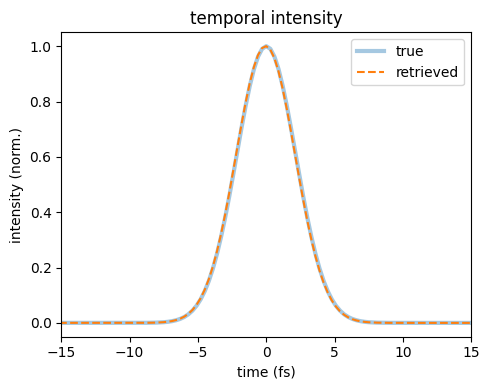

In [6]:
def center(t, intensity):
    """Shift so the peak sits at t=0 and normalise the peak to 1."""
    i = int(np.argmax(intensity))
    return t - t[i], intensity / intensity.max()

t_true, I_true_n = center(g.t, I_true)
t_retr, I_retr_n = center(res.t, res.intensity_t)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(t_true * 1e15, I_true_n, lw=3, alpha=0.4, label="true")
ax.plot(t_retr * 1e15, I_retr_n, "--", lw=1.5, label="retrieved")
ax.set_xlim(-15, 15)
ax.set_xlabel("time (fs)")
ax.set_ylabel("intensity (norm.)")
ax.legend()
ax.set_title("temporal intensity")
fig.tight_layout()

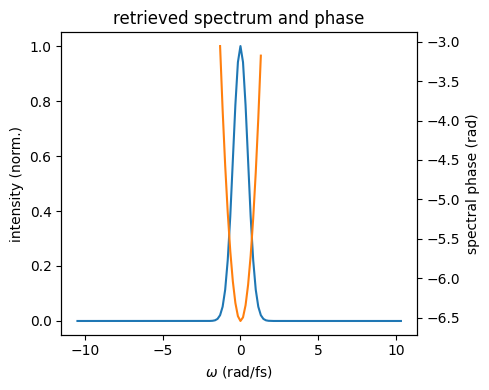

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(g.omega / 1e15, res.intensity_omega / res.intensity_omega.max(),
        label="spectral intensity")
ax2 = ax.twinx()
mask = res.intensity_omega > 0.02 * res.intensity_omega.max()
ax2.plot(g.omega[mask] / 1e15, res.phase_omega[mask], "C1", label="phase")
ax.set_xlabel(r"$\omega$ (rad/fs)")
ax.set_ylabel("intensity (norm.)")
ax2.set_ylabel("spectral phase (rad)")
ax.set_title("retrieved spectrum and phase")
fig.tight_layout()

In [8]:
truth = croak.TruthPulse.from_spectrum(g, ew, omega0)
res, flipped = croak.resolve_time_direction(res, truth)
print(f"time direction flipped to match the truth: {flipped}")

time direction flipped to match the truth: False


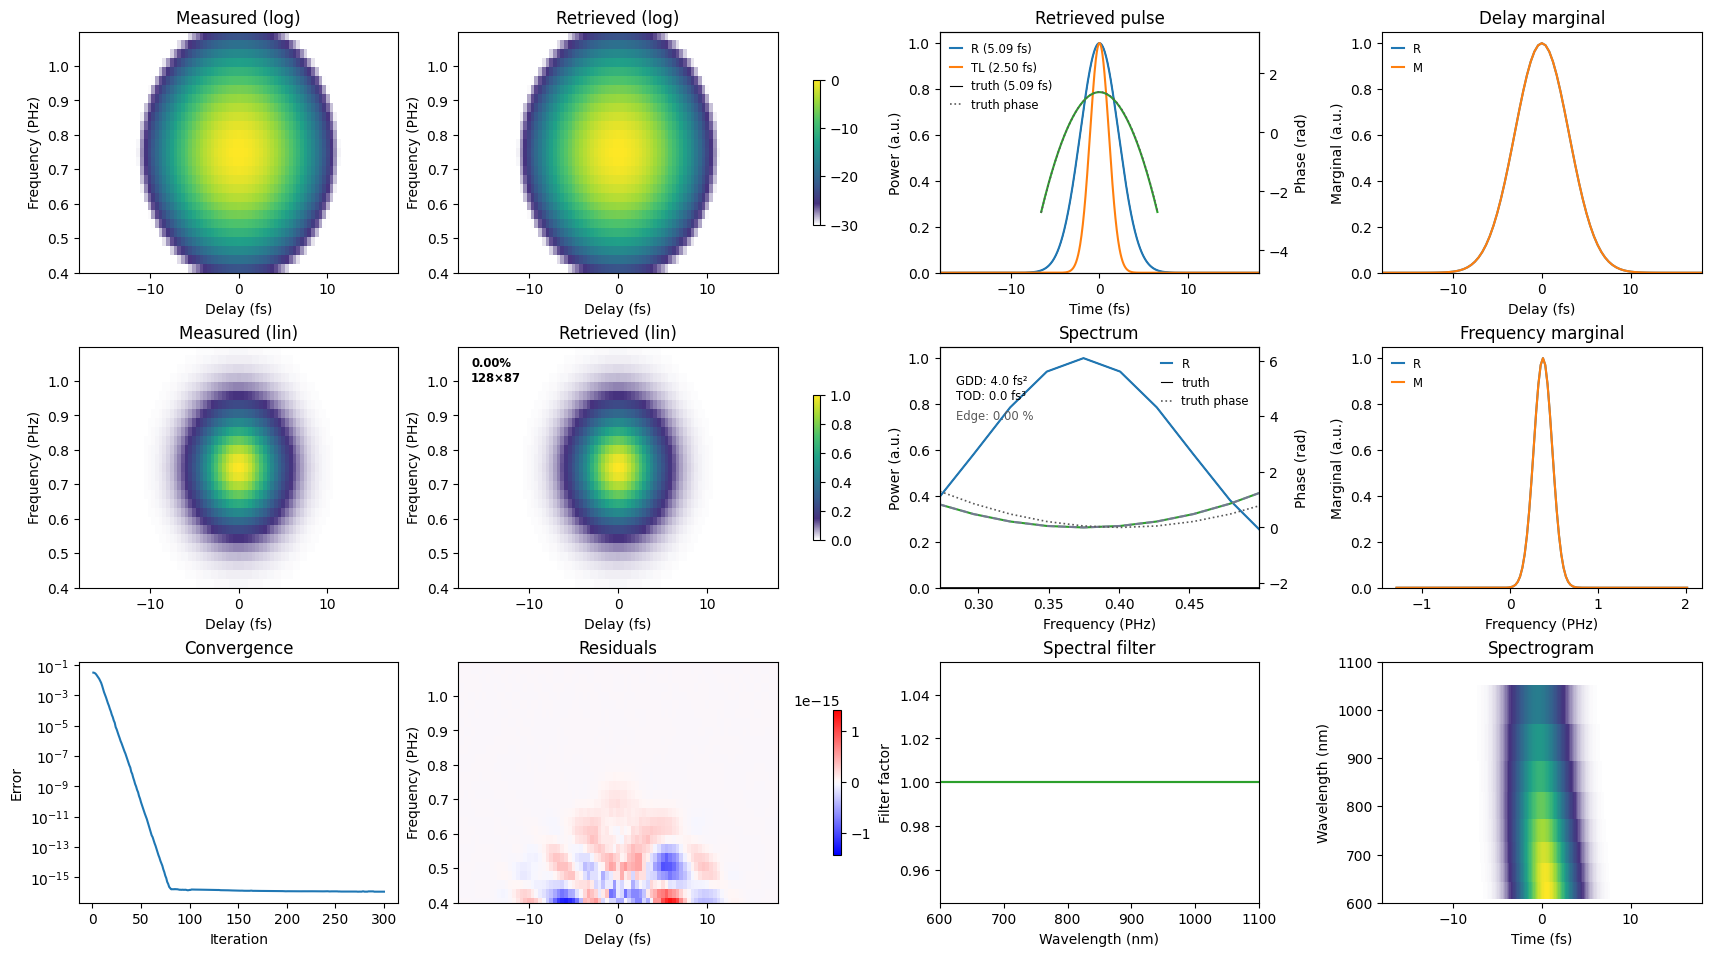

In [9]:
f0 = omega0 / (2 * np.pi)                       # SHG signal sits at 2*f0
fig = croak.plot_retrieval(res, measured=trace, truth=truth,
                           lam_min=600e-9, lam_max=1100e-9,
                           flim=(2 * f0 - 0.35e15, 2 * f0 + 0.35e15))
fig      # croak builds Figures without pyplot, so return it to display it